In [23]:
import pyproj
import math
import numpy as np
import matplotlib.pyplot as plt

from math import sin, cos, tan, atan, asin, sqrt, ceil, floor


In [24]:
frequency_hz = 5_000_000_000
latA, lonA, altA_m = (40.650, -73.800, 100.0)
latB, lonB, altB_m = (40.7173, -74.0060, 10000.0)
alpha = 0.8
t = 12000

In [25]:
nys_crs = pyproj.CRS.from_string("EPSG:6539+6360")
gps_crs = pyproj.CRS.from_string("EPSG:4326+5773")
t_to_nys = pyproj.Transformer.from_crs(gps_crs, nys_crs, always_xy=False)
xA, yA, zA = t_to_nys.transform(latA, lonA, altA_m)
xB, yB, zB = t_to_nys.transform(latB, lonB, altB_m)


deltaX = xB - xA
deltaY = yB - yA
deltaZ = zB - zA

xC, yC, zC = (xA + xB) / 2, (yA + yB) / 2, (zA + zB) / 2

L = sqrt(deltaX**2 + deltaY**2 + deltaZ**2)

In [26]:
theta = atan(-deltaY/deltaX)
phi = atan(-deltaZ/deltaX)

rho = asin(deltaZ/L)
rho2 = atan(tan(phi) * cos(theta))

omega = atan(cos(theta) / (sin(theta) * cos(phi)))

theta_deg = math.degrees(theta)
phi_deg = math.degrees(phi)
rho_deg = math.degrees(rho)
omega_deg = math.degrees(omega)


In [27]:
# Alternative construction of y hat with norm instead of angles
y_hat = np.append(np.array([deltaX, deltaY, deltaZ]) / L, 1)

In [28]:
R_ellipsoid_to_global = np.array([
    [cos(phi) * sin(theta) * cos(rho), - cos(theta) * cos(rho), sin(phi), 0],
    [sin(rho) * sin(phi) + cos(phi) * cos(theta) * cos(rho), sin(theta) * cos(rho), 0, 0],
    [-sin(phi) * cos(rho) * sin(theta), sin(rho), cos(phi), 0],
    [0, 0, 0, 1],
])


In [29]:
speed_of_light = 299_792_458 # m/s
wavelength_meters = speed_of_light / frequency_hz
wavelength_usft = wavelength_meters / 0.30480061

semi_major = (L + wavelength_usft / 2) / 2
semi_minor = (sqrt(wavelength_usft * L) / 2) * alpha
Q_pure_fresnel = np.diag([
    1/semi_minor**2,
    1/semi_major**2,
    1/semi_minor**2,
    -1
])

max_t = np.linalg.norm(np.array([semi_minor, semi_major]) * np.array([sin(omega), cos(omega)]))
t_bounds = (-max_t, max_t)
t_bounds


(np.float64(-12228.11834828034), np.float64(12228.11834828034))

In [30]:
T_centered_to_global = np.array([
    [1, 0, 0, xC],
    [0, 1, 0, yC],
    [0, 0, 1, zC],
    [0, 0, 0, 1]
])
T_centered_to_global

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.01116723e+06],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.88380286e+05],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.65682083e+04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [31]:
A_ellipsoid_to_global = T_centered_to_global @ R_ellipsoid_to_global
A_global_to_ellipsoid = np.linalg.inv(A_ellipsoid_to_global)

### Validate the coordinate transformations behave as expected for some test points

In [32]:
A_global_to_ellipsoid @ np.array([xC, yC, zC, 1]) - np.array([0, 0, 0, 1])

array([ 0.00000000e+00,  1.16415322e-10, -5.82076609e-11,  0.00000000e+00])

In [33]:
A_ellipsoid_to_global @ np.array([0, L / 2, 0, 1]) - np.array([xB, yB, zB, 1])

array([0., 0., 0., 0.])

In [34]:
A_ellipsoid_to_global @ np.array([0, 0, 0, 1]) - np.array([xC, yC, zC, 1])


array([0., 0., 0., 0.])

In [35]:
A_ellipsoid_to_global @ np.array([0, -L / 2, 0, 1]) - np.array([xA, yA, zA, 1])

array([1.16415322e-10, 0.00000000e+00, 5.68434189e-13, 0.00000000e+00])

### Compute the intersection

In [36]:
Q_global = np.linalg.matrix_transpose(A_global_to_ellipsoid) @ Q_pure_fresnel @ A_global_to_ellipsoid
np.linalg.inv(Q_global)

array([[-1.02164230e+12, -1.90833451e+11, -1.72173801e+10,
        -1.01116721e+06],
       [-1.90833451e+11, -3.53376046e+10, -2.92253897e+09,
        -1.88380283e+05],
       [-1.72173801e+10, -2.92253897e+09, -1.07613894e+07,
        -1.65682081e+04],
       [-1.01116721e+06, -1.88380283e+05, -1.65682081e+04,
        -9.99999985e-01]])

In [37]:
# For reference, the center coordinates, which should agree with inv(Q_global) @ [0, 0, 0, -1]
xC, yC, zC

(1011167.2277252311, 188380.2855814694, 16568.208333333336)

In [38]:
E_global = np.array([
    [1, 0, xC],
    [0, 0, yC + t],
    [0, 1, zC],
    [0, 0, 1]
])
E_global

array([[1.00000000e+00, 0.00000000e+00, 1.01116723e+06],
       [0.00000000e+00, 0.00000000e+00, 2.00380286e+05],
       [0.00000000e+00, 1.00000000e+00, 1.65682083e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [39]:
C = np.linalg.matrix_transpose(E_global) @ Q_global @ E_global
np.linalg.inv(C)

array([[-2.12821420e+10,  1.20930324e+10,  7.58800256e+05],
       [ 1.20930324e+10, -6.87155317e+09, -4.31168777e+05],
       [ 7.58800256e+05, -4.31168777e+05, -2.70544874e+01]])

In [40]:
ellipse_offset_homogenous = np.linalg.inv(C)[:, 2]

ellipse_offset = ellipse_offset_homogenous[:2] / ellipse_offset_homogenous[2]

In [41]:
B_ellipse_normalization = np.array([
    [1, 0, ellipse_offset[0]],
    [0, 1, ellipse_offset[1]],
    [0, 0, 1]
])

In [42]:
C_norm = np.linalg.matrix_transpose(B_ellipse_normalization) @ C @ B_ellipse_normalization

a = C_norm[0, 0]
b = C_norm[1, 0]
c = C_norm[1, 1]
f = C_norm[2, 2]

C_norm

array([[ 1.52170546e-04,  1.70906002e-04,  8.88178420e-16],
       [ 1.70906002e-04,  3.55829648e-04,  1.55431223e-15],
       [ 8.88178420e-16,  1.55431223e-15, -3.69624449e-02]])

In [43]:
max_x_offset = sqrt(c*f/(b**2-a*c))
min_x_offset = -sqrt(c*f/(b**2-a*c))
x_offset_bounds = np.array((min_x_offset, max_x_offset))
x_offset_bounds

array([-22.9652515,  22.9652515])

In [44]:
# __BOTH__ BOUNDS ARE __INCLUSIVE__
ellipse_offset_global_x_offset = ellipse_offset[0] + xC
x_bounds_global = ellipse_offset_global_x_offset + x_offset_bounds
x_grid_bounds_global = np.array([ceil(x_bounds_global[0]), floor(x_bounds_global[1])])

x_grid_width = x_grid_bounds_global[1] - x_grid_bounds_global[0]
x_grid_bounds_ellipse = x_grid_bounds_global - ellipse_offset_global_x_offset
x_grid_ellipse = np.linspace(x_grid_bounds_ellipse[0], x_grid_bounds_ellipse[1], x_grid_width + 1) # +1 is to convert width to an inclusive upper bound
x_grid_ellipse

array([-22.11507626, -21.11507626, -20.11507626, -19.11507626,
       -18.11507626, -17.11507626, -16.11507626, -15.11507626,
       -14.11507626, -13.11507626, -12.11507626, -11.11507626,
       -10.11507626,  -9.11507626,  -8.11507626,  -7.11507626,
        -6.11507626,  -5.11507626,  -4.11507626,  -3.11507626,
        -2.11507626,  -1.11507626,  -0.11507626,   0.88492374,
         1.88492374,   2.88492374,   3.88492374,   4.88492374,
         5.88492374,   6.88492374,   7.88492374,   8.88492374,
         9.88492374,  10.88492374,  11.88492374,  12.88492374,
        13.88492374,  14.88492374,  15.88492374,  16.88492374,
        17.88492374,  18.88492374,  19.88492374,  20.88492374,
        21.88492374,  22.88492374])

In [45]:
sqrt_term = np.sqrt(x_grid_ellipse**2 * ((b**2 - a*c) / c**2) - (f / c))
lin_term = (-b/c) * x_grid_ellipse

lower_bounds_ellipse = lin_term - sqrt_term
upper_bounds_ellipse = lin_term + sqrt_term
lower_bounds_ellipse, upper_bounds_ellipse

(array([  7.87444646,   6.13373143,   4.74361391,   3.53207409,
          2.43626173,   1.42465855,   0.47875666,  -0.41341321,
         -1.26011331,  -2.0673196 ,  -2.83950655,  -3.58011308,
         -4.2918348 ,  -4.9768156 ,  -5.63677779,  -6.27311298,
         -6.88694703,  -7.47918716,  -8.05055659,  -8.60162001,
         -9.13280217,  -9.64440116, -10.1365974 , -10.60945885,
        -11.06294303, -11.49689575, -11.91104665, -12.30500112,
        -12.67822814, -13.03004293, -13.35958332, -13.66577742,
        -13.94729979, -14.20251117, -14.42937451, -14.62533547,
        -14.78714758, -14.91060804, -14.99014106, -15.01810573,
        -14.98356587, -14.86989878, -14.64952565, -14.2698566 ,
        -13.60060514, -11.84340392]),
 array([ 13.3694228 ,  14.14953209,  14.57904386,  14.82997794,
         14.96518455,  15.016182  ,  15.00147814,  14.93304226,
         14.81913663,  14.66573717,  14.47731838,  14.25731917,
         14.00843514,  13.7328102 ,  13.43216665,  13.1078961 ,
  

In [46]:
ellipse_offset_global_z_offset = ellipse_offset[1] + zC
lower_bounds_global, upper_bounds_global = lower_bounds_ellipse + ellipse_offset_global_z_offset, upper_bounds_ellipse + ellipse_offset_global_z_offset
lower_bounds_global, upper_bounds_global

(array([32513.13491572, 32511.39420069, 32510.00408317, 32508.79254335,
        32507.69673099, 32506.68512781, 32505.73922592, 32504.84705606,
        32504.00035595, 32503.19314966, 32502.42096271, 32501.68035618,
        32500.96863446, 32500.28365366, 32499.62369147, 32498.98735628,
        32498.37352223, 32497.7812821 , 32497.20991267, 32496.65884925,
        32496.1276671 , 32495.6160681 , 32495.12387186, 32494.65101041,
        32494.19752623, 32493.76357351, 32493.34942261, 32492.95546814,
        32492.58224112, 32492.23042633, 32491.90088594, 32491.59469184,
        32491.31316947, 32491.05795809, 32490.83109475, 32490.63513379,
        32490.47332168, 32490.34986122, 32490.2703282 , 32490.24236353,
        32490.2769034 , 32490.39057048, 32490.61094361, 32490.99061266,
        32491.65986412, 32493.41706534]),
 array([32518.62989206, 32519.41000135, 32519.83951312, 32520.0904472 ,
        32520.22565382, 32520.27665126, 32520.2619474 , 32520.19351153,
        32520.07960589

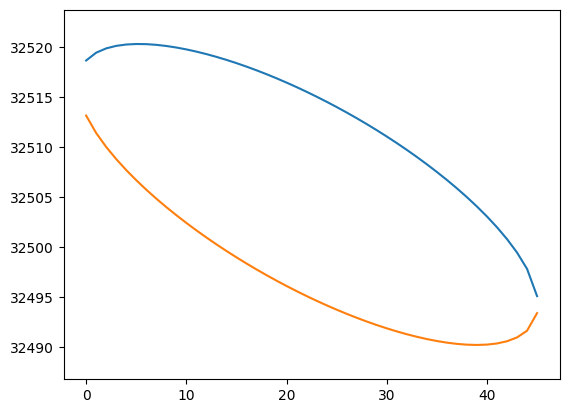

In [47]:
plt.plot(upper_bounds_global)
plt.plot(lower_bounds_global)
ax = plt.gca()
ax.set_aspect('equal', adjustable='datalim')
